# German Electricity Demand — Time Series Modelling Case Study




## Setup

In [1]:
# Run once per Colab session
!pip install -q statsmodels scikit-learn tensorflow requests pyarrow

import warnings
warnings.filterwarnings("ignore")

import itertools
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras import layers, models

RESULTS = {}  # model_name -> {"rmse", "mae", "mape_pct", "forecast": pd.Series}
HORIZON_WEEKS = 104   # 2 years of weekly data, used for all weekly models
SEASONAL_PERIOD = 52  # weeks per year

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def log_result(name, y_true, y_pred):
    RESULTS[name] = {
        "rmse": rmse(y_true, y_pred), "mae": mae(y_true, y_pred), "mape_pct": mape(y_true, y_pred),
        "forecast": pd.Series(np.asarray(y_pred), index=y_true.index),
    }
    r = RESULTS[name]
    print(f"{name}: RMSE={r['rmse']:.1f}  MAE={r['mae']:.1f}  MAPE={r['mape_pct']:.2f}%")


## Part 1: Data acquisition, preparation, initial EDA



In [2]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to file in MyDrive
RAW_CSV = Path('/content/drive/MyDrive/time_series_60min_singleindex.csv')

# Check file exists
if not RAW_CSV.exists():
    raise FileNotFoundError(
        f"File not found at: {RAW_CSV}\n"
        "Please upload time_series_60min_singleindex.csv to your Google Drive MyDrive folder."
    )

LOAD_COL = "DE_load_actual_entsoe_transparency"
START_DATE = "2015-01-01"

Mounted at /content/drive


In [3]:
def load_de_load_series(csv_path, start_date=START_DATE):
    """Load the OPSD CSV and return the hourly German load series, filtered to
    start_date -> end of file. Only reads the two columns we need - the full file
    has 70+ columns covering every European country."""
    df = pd.read_csv(csv_path, usecols=["utc_timestamp", LOAD_COL], parse_dates=["utc_timestamp"])
    df = df.rename(columns={"utc_timestamp": "timestamp", LOAD_COL: "load_mw"}).set_index("timestamp").sort_index()
    df = df.loc[df.index >= pd.Timestamp(start_date, tz="UTC")]
    n_missing = df["load_mw"].isna().sum()
    if n_missing:
        print(f"{n_missing} missing hourly values found - forward-filling")
        df["load_mw"] = df["load_mw"].ffill()
    return df["load_mw"]

def resample_series(hourly, freq, agg="mean"):
    return hourly.resample(freq).agg(agg)

hourly = load_de_load_series(RAW_CSV)
daily = resample_series(hourly, "D")
weekly = resample_series(hourly, "W")
weekly.index.freq = "W-SUN"

print(f"hourly: {hourly.shape}, daily: {daily.shape}, weekly: {weekly.shape}")
print(f"date range: {hourly.index.min()} -> {hourly.index.max()}")


hourly: (50400,), daily: (2100,), weekly: (301,)
date range: 2015-01-01 00:00:00+00:00 -> 2020-09-30 23:00:00+00:00


### Initial time series plots

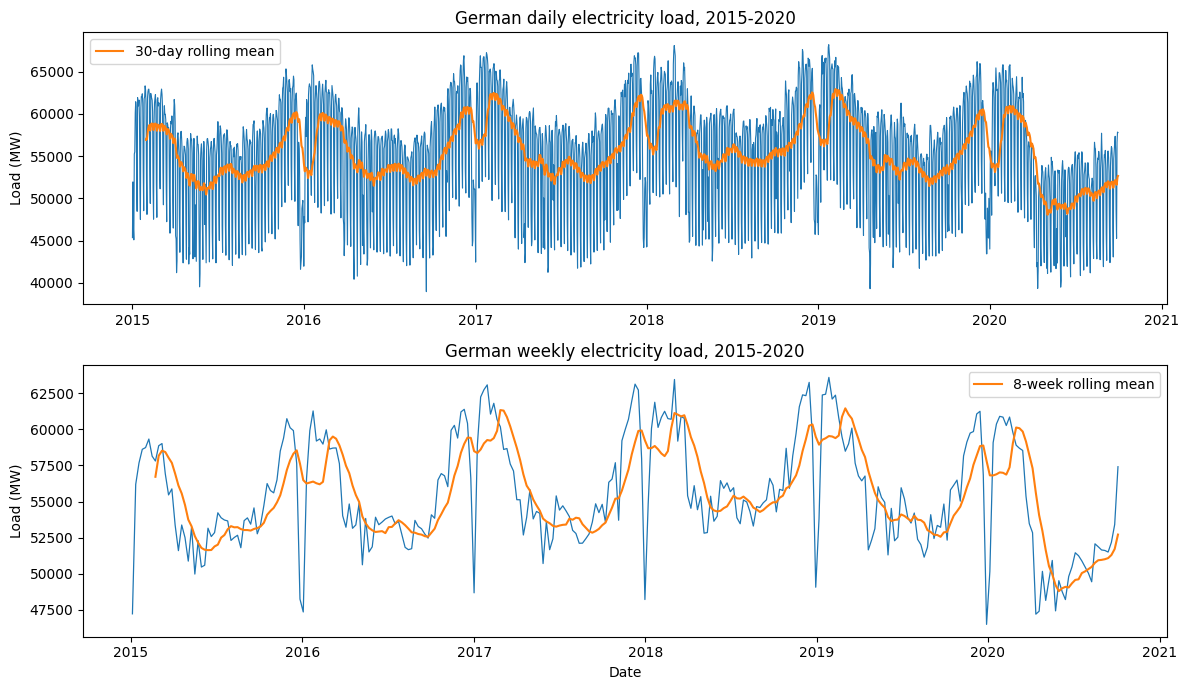

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].plot(daily.index, daily.rolling(30).mean(), linewidth=1.5, label="30-day rolling mean")
axes[0].set_title("German daily electricity load, 2015-2020")
axes[0].set_ylabel("Load (MW)")
axes[0].legend()

axes[1].plot(weekly.index, weekly.values, linewidth=0.9)
axes[1].plot(weekly.index, weekly.rolling(8).mean(), linewidth=1.5, label="8-week rolling mean")
axes[1].set_title("German weekly electricity load, 2015-2020")
axes[1].set_ylabel("Load (MW)")
axes[1].set_xlabel("Date")
axes[1].legend()
fig.tight_layout()
plt.show()


### Components and seasonality




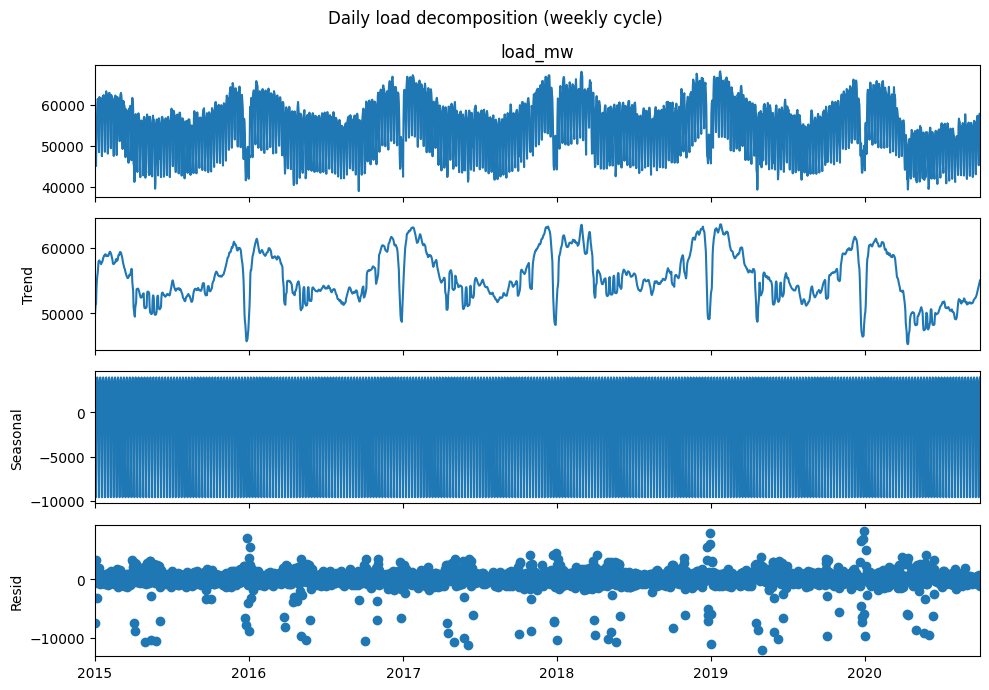

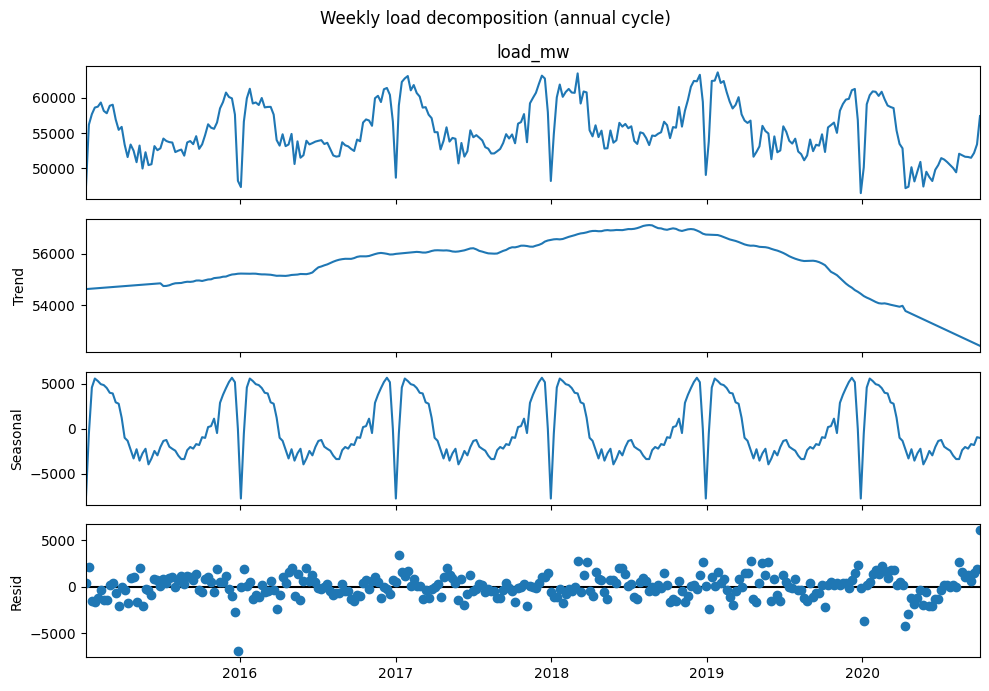

In [5]:
result_daily = seasonal_decompose(daily, model="additive", period=7, extrapolate_trend="freq")
fig = result_daily.plot(); fig.set_size_inches(10, 7); fig.suptitle("Daily load decomposition (weekly cycle)"); fig.tight_layout(); plt.show()

result_weekly = seasonal_decompose(weekly, model="additive", period=52, extrapolate_trend="freq")
fig = result_weekly.plot(); fig.set_size_inches(10, 7); fig.suptitle("Weekly load decomposition (annual cycle)"); fig.tight_layout(); plt.show()


### Stationarity testing (ADF + KPSS, ACF/PACF)




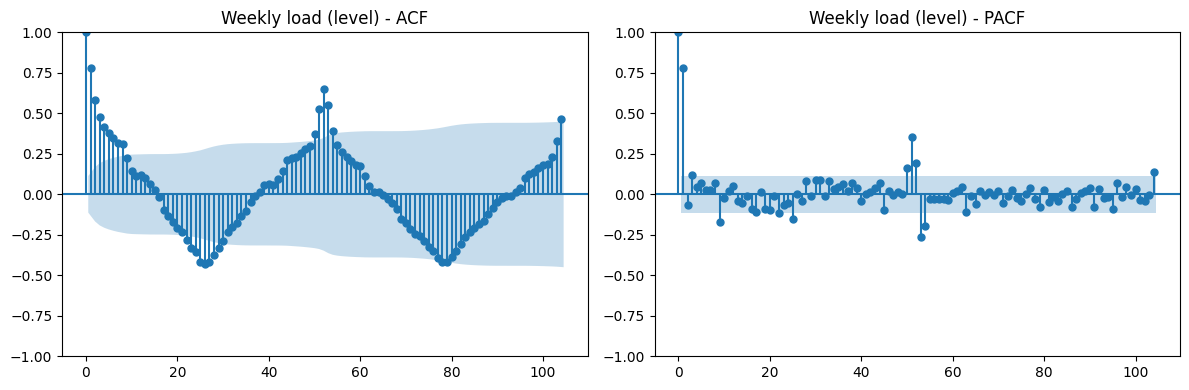

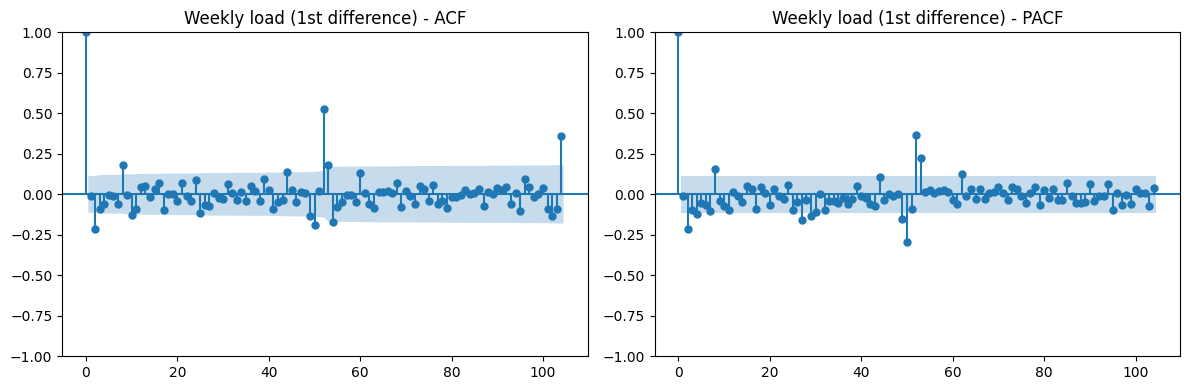

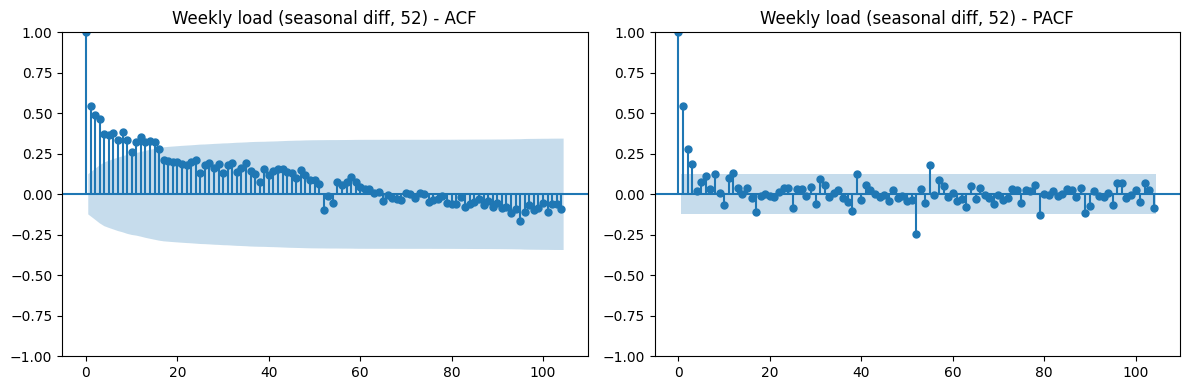

/tmp/ipykernel_378/3010189828.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_378/3010189828.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_378/3010189828.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


,series,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,weekly_level,-4.047472,1.181350e-03,True,0.160374,0.10,True
1,weekly_diff1,-7.069318,4.984737e-10,True,0.055754,0.10,True
2,weekly_seasonal_diff52,-4.295072,4.530219e-04,True,1.341877,0.01,False


In [6]:
def plot_acf_pacf(series, lags, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), lags=lags, ax=axes[0]); axes[0].set_title(f"{title_prefix} - ACF")
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm"); axes[1].set_title(f"{title_prefix} - PACF")
    fig.tight_layout(); plt.show()

def stationarity_tests(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "series": label, "adf_stat": adf_stat, "adf_pvalue": adf_p, "adf_stationary_5pct": adf_p < 0.05,
        "kpss_stat": kpss_stat, "kpss_pvalue": kpss_p, "kpss_stationary_5pct": kpss_p > 0.05,
    }

plot_acf_pacf(weekly, 104, "Weekly load (level)")
plot_acf_pacf(weekly.diff().dropna(), 104, "Weekly load (1st difference)")
plot_acf_pacf(weekly.diff(52).dropna(), 104, "Weekly load (seasonal diff, 52)")

stat_results = pd.DataFrame([
    stationarity_tests(weekly, "weekly_level"),
    stationarity_tests(weekly.diff().dropna(), "weekly_diff1"),
    stationarity_tests(weekly.diff(52).dropna(), "weekly_seasonal_diff52"),
])
stat_results


## Part 2: Benchmark models




mean: RMSE=4397.3  MAE=3788.8  MAPE=6.97%
naive: RMSE=4459.1  MAE=3783.2  MAPE=6.79%
seasonal_naive: RMSE=3006.8  MAE=2318.5  MAPE=4.41%
drift: RMSE=5118.0  MAE=4339.9  MAPE=8.05%


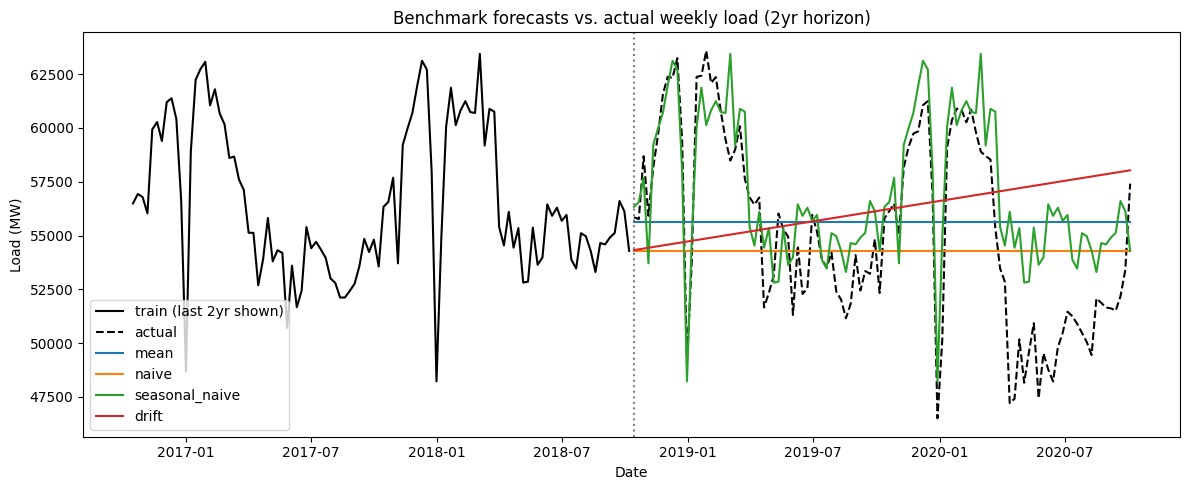

In [7]:
def train_test_split(series, horizon=HORIZON_WEEKS):
    return series.iloc[:-horizon], series.iloc[-horizon:]

def mean_forecast(train, horizon):
    return np.full(horizon, train.mean())

def naive_forecast(train, horizon):
    return np.full(horizon, train.iloc[-1])

def seasonal_naive_forecast(train, horizon, period=SEASONAL_PERIOD):
    last_season = train.iloc[-period:].values
    reps = int(np.ceil(horizon / period))
    return np.tile(last_season, reps)[:horizon]

def drift_forecast(train, horizon):
    y1, yT, T = train.iloc[0], train.iloc[-1], len(train)
    slope = (yT - y1) / (T - 1)
    return yT + slope * np.arange(1, horizon + 1)

train_w, test_w = train_test_split(weekly)

benchmark_forecasts = {
    "mean": mean_forecast(train_w, len(test_w)),
    "naive": naive_forecast(train_w, len(test_w)),
    "seasonal_naive": seasonal_naive_forecast(train_w, len(test_w)),
    "drift": drift_forecast(train_w, len(test_w)),
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_w.index[-104:], train_w.iloc[-104:], label="train (last 2yr shown)", color="black")
ax.plot(test_w.index, test_w.values, label="actual", color="black", linestyle="--")
for name, fc in benchmark_forecasts.items():
    ax.plot(test_w.index, fc, label=name)
    log_result(name, test_w, fc)
ax.axvline(test_w.index[0], color="grey", linestyle=":")
ax.set_title("Benchmark forecasts vs. actual weekly load (2yr horizon)")
ax.set_xlabel("Date"); ax.set_ylabel("Load (MW)"); ax.legend()
fig.tight_layout(); plt.show()


## Part 3: SARIMA (AIC grid search)



In [8]:
import itertools
import time
import warnings
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

t0 = time.time()

p_values = range(0, 6)
d_values = range(0, 2)
q_values = range(0, 6)

SEASONAL_PERIOD = 52
SEASONAL_ORDER = (1, 0, 1, SEASONAL_PERIOD)

combos = list(itertools.product(p_values, d_values, q_values))

grid_results = []

for i, (p, d, q) in enumerate(combos, start=1):
    try:
        fit = SARIMAX(
            train_w,
            order=(p, d, q),
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=50)

        grid_results.append({
            "p": p,
            "d": d,
            "q": q,
            "aic": fit.aic
        })

        print(f"{i}/{len(combos)} fitted: order=({p},{d},{q}), AIC={fit.aic:.2f}")

    except Exception as e:
        grid_results.append({
            "p": p,
            "d": d,
            "q": q,
            "aic": None,
            "error": str(e)[:100]
        })

        print(f"{i}/{len(combos)} failed: order=({p},{d},{q})")

grid_df = pd.DataFrame(grid_results)

grid_df = (
    grid_df
    .dropna(subset=["aic"])
    .sort_values("aic")
    .reset_index(drop=True)
)

print(f"Grid search finished in {(time.time() - t0) / 60:.2f} minutes")

display(grid_df.head(10))

best_p, best_d, best_q = grid_df.loc[0, ["p", "d", "q"]].astype(int)

print("Best SARIMA order:", (best_p, best_d, best_q))
print("Seasonal order:", SEASONAL_ORDER)


1/72 fitted: order=(0,0,0), AIC=5014.88
2/72 fitted: order=(0,0,1), AIC=161283.00
3/72 fitted: order=(0,0,2), AIC=152103.16
4/72 fitted: order=(0,0,3), AIC=154836.05
5/72 fitted: order=(0,0,4), AIC=141870.53
6/72 fitted: order=(0,0,5), AIC=148187.51
7/72 fitted: order=(0,1,0), AIC=5283.65
8/72 fitted: order=(0,1,1), AIC=3814.19
9/72 fitted: order=(0,1,2), AIC=5346.53
10/72 fitted: order=(0,1,3), AIC=7197.65
11/72 fitted: order=(0,1,4), AIC=4744.24
12/72 fitted: order=(0,1,5), AIC=8351.25
13/72 fitted: order=(1,0,0), AIC=4772.62
14/72 fitted: order=(1,0,1), AIC=2230.48
15/72 fitted: order=(1,0,2), AIC=7624.30
16/72 fitted: order=(1,0,3), AIC=5173.17
17/72 fitted: order=(1,0,4), AIC=6352.73
18/72 fitted: order=(1,0,5), AIC=4849.24
19/72 fitted: order=(1,1,0), AIC=11042.58
20/72 fitted: order=(1,1,1), AIC=1160.93
21/72 fitted: order=(1,1,2), AIC=7184.55
22/72 fitted: order=(1,1,3), AIC=9500.88
23/72 fitted: order=(1,1,4), AIC=544.88
24/72 fitted: order=(1,1,5), AIC=2869.66
25/72 fitted: o

,p,d,q,aic
0,5,1,5,129.864478
1,3,0,5,306.865199
2,1,1,4,544.882259
3,5,1,1,858.816583
4,2,0,1,1118.062807
5,4,1,2,1118.092248
6,1,1,1,1160.927273
7,3,0,1,1263.707405
8,4,1,4,1744.989138
9,1,0,1,2230.475972


Best SARIMA order: (5, 1, 5)
Seasonal order: (1, 0, 1, 52)


In [10]:
best_p, best_d, best_q = grid_df.iloc[0][["p", "d", "q"]].astype(int)
print(f"Best model by AIC: SARIMA({best_p},{best_d},{best_q})x{SEASONAL_ORDER}, AIC={grid_df.iloc[0]['aic']:.1f}")

sarima_fit = SARIMAX(
    train_w, order=(best_p, best_d, best_q), seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=100)
print(sarima_fit.summary())


Best model by AIC: SARIMA(5,1,5)x(1, 0, 1, 52), AIC=129.9
                                      SARIMAX Results                                       
Dep. Variable:                              load_mw   No. Observations:                  197
Model:             SARIMAX(5, 1, 5)x(1, 0, [1], 52)   Log Likelihood                 -51.932
Date:                              Sun, 12 Jul 2026   AIC                            129.864
Time:                                      19:25:18   BIC                            167.919
Sample:                                  01-04-2015   HQIC                           145.329
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          7.1289      0.008    904.

### Residual diagnostics

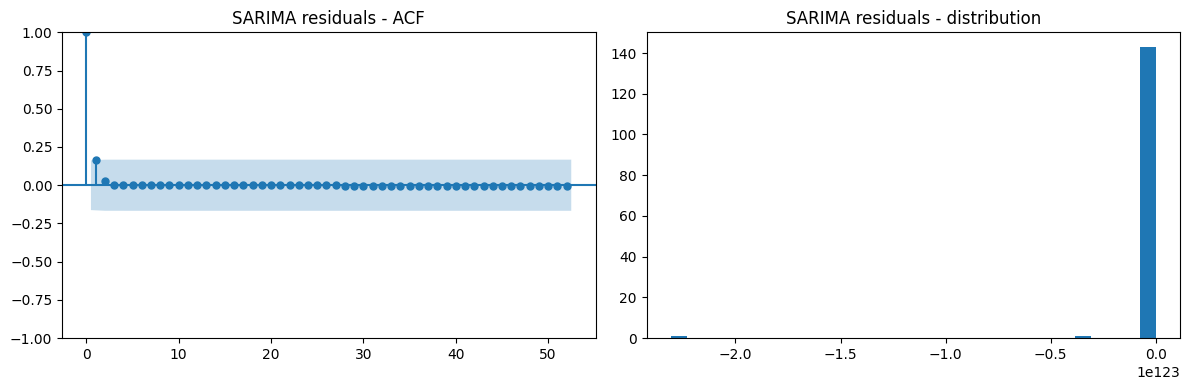

Residual mean: -1.9039790050187578e+121  std: 1.9398179567522133e+122


In [11]:
resid = sarima_fit.resid[SEASONAL_PERIOD:]  # drop the seasonal warm-up period

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=52, ax=axes[0]); axes[0].set_title("SARIMA residuals - ACF")
axes[1].hist(resid, bins=30); axes[1].set_title("SARIMA residuals - distribution")
fig.tight_layout(); plt.show()

print("Residual mean:", resid.mean(), " std:", resid.std())


### Forecast, confidence intervals, RMSE

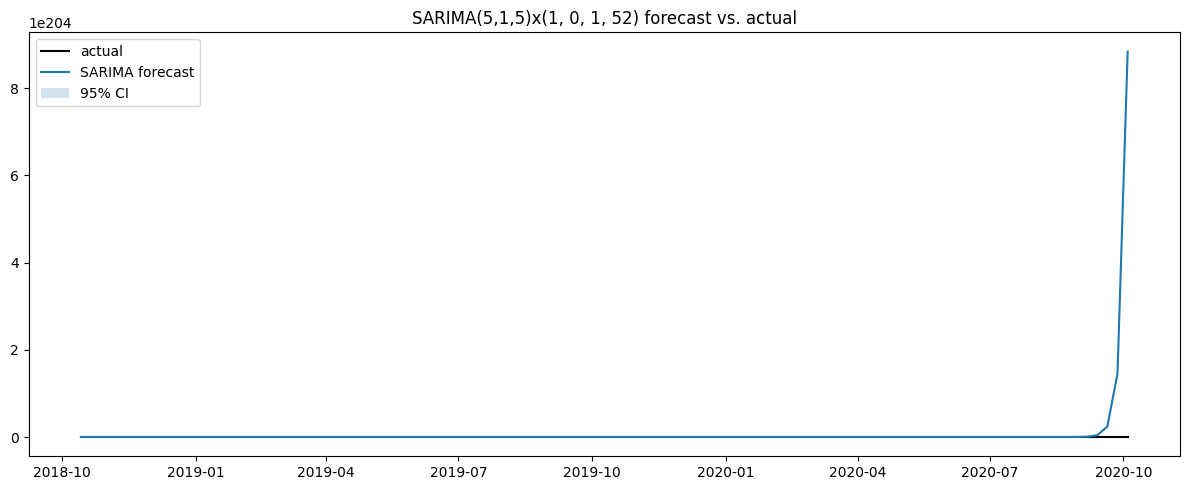

sarima: RMSE=inf  MAE=101704069528885321235308683053043630072640549657989447166368731421683711183036406680970101522703863890987928290908622825468002831335041768401370500922288745376680452975322717572940236807256943804127641600.0  MAPE=179463482954910699310535738772004838164960843710111295467195949817074269663725864326898844843100526189555917312709199142767196834568263250601149415026734943467735309495505070028348044008978892422381568.00%


In [12]:
sarima_fc = sarima_fit.get_forecast(steps=HORIZON_WEEKS)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_w.index, test_w.values, label="actual", color="black")
ax.plot(test_w.index, sarima_pred.values, label="SARIMA forecast")
ax.fill_between(test_w.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2, label="95% CI")
ax.set_title(f"SARIMA({best_p},{best_d},{best_q})x{SEASONAL_ORDER} forecast vs. actual")
ax.legend(); fig.tight_layout(); plt.show()

log_result("sarima", test_w, sarima_pred.values)


## Part 4: Temperature exogenous variable -> SARIMAX




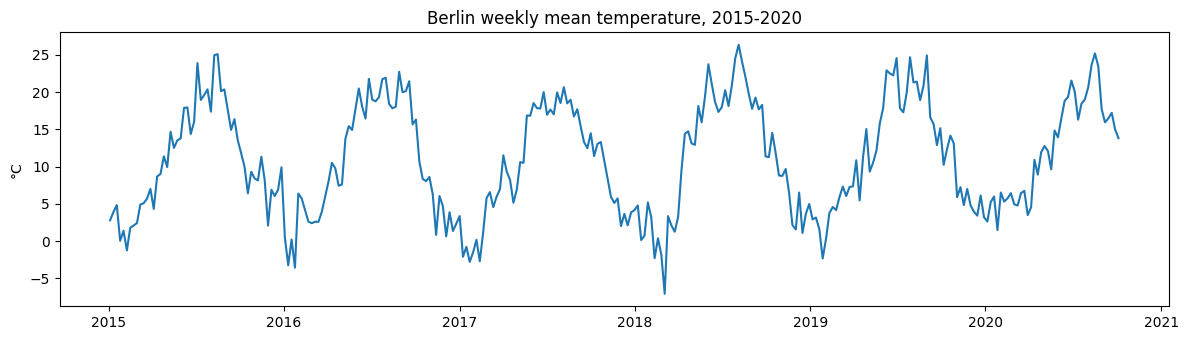

In [13]:
import requests

BERLIN_LAT, BERLIN_LON = 52.52, 13.41

def fetch_berlin_temperature(start_date, end_date):
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={BERLIN_LAT}&longitude={BERLIN_LON}"
        f"&start_date={start_date}&end_date={end_date}"
        "&daily=temperature_2m_mean&timezone=UTC"
    )
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    js = r.json()
    df = pd.DataFrame({"date": js["daily"]["time"], "temp_c": js["daily"]["temperature_2m_mean"]})
    df["date"] = pd.to_datetime(df["date"], utc=True)
    return df.set_index("date")["temp_c"].resample("W").mean()

temp_weekly = fetch_berlin_temperature(weekly.index.min().date(), weekly.index.max().date())
temp_weekly = temp_weekly.reindex(weekly.index).ffill().bfill()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(temp_weekly.index, temp_weekly.values)
ax.set_title("Berlin weekly mean temperature, 2015-2020"); ax.set_ylabel("°C")
fig.tight_layout(); plt.show()


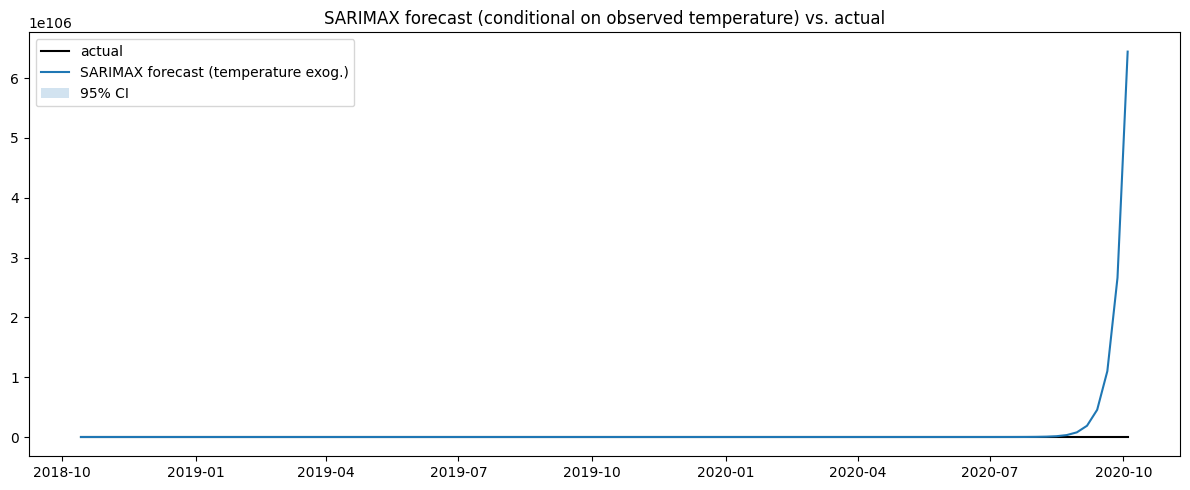

sarimax_temperature: RMSE=6939203129161204505835058439129353529205607592314017635247075533999953645532833751235597457933459225837568.0  MAE=1056201275733057154127873155968434050923680537720761365323397019899672292025978908081385140754978367864832.0  MAPE=1906387603625464362400096760960216209455026806211259862428272849367256884259671888302143996335962980352.00%
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_c      -140.4328      6.859    -20.473      0.000    -153.877    -126.989
ar.L1         -0.5374      0.079     -6.833      0.000      -0.692      -0.383
ar.L2          4.4878      0.010    448.228      0.000       4.468       4.507
ar.L3          4.1580      0.164     25.289      0.000       3.836       4.480
ar.L4          4.2502      0.069     61.391      0.000       4.114       4.386
ar.L5          3.1001      0.057     54.364      0.000       2.988       3.212
ma.L1

In [14]:
train_temp, test_temp = temp_weekly.iloc[:-HORIZON_WEEKS], temp_weekly.iloc[-HORIZON_WEEKS:]

sarimax_fit = SARIMAX(
    train_w, exog=train_temp, order=(best_p, best_d, best_q), seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=100)

sarimax_fc = sarimax_fit.get_forecast(steps=HORIZON_WEEKS, exog=test_temp)
sarimax_pred = sarimax_fc.predicted_mean
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_w.index, test_w.values, label="actual", color="black")
ax.plot(test_w.index, sarimax_pred.values, label="SARIMAX forecast (temperature exog.)")
ax.fill_between(test_w.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1], alpha=0.2, label="95% CI")
ax.set_title("SARIMAX forecast (conditional on observed temperature) vs. actual")
ax.legend(); fig.tight_layout(); plt.show()

log_result("sarimax_temperature", test_w, sarimax_pred.values)
print(sarimax_fit.summary().tables[1])  # coefficient table, incl. temperature coefficient


## Part 5: Feature-based regression model (Random Forest / Gradient Boosting)




random_forest: RMSE=3021.1  MAE=2277.6  MAPE=4.39%
random_forest feature importances: {'temp_c': np.float64(0.04), 'lag_1': np.float64(0.067), 'lag_2': np.float64(0.013), 'lag_52': np.float64(0.812), 'roll_mean_4': np.float64(0.019), 'woy_sin': np.float64(0.005), 'woy_cos': np.float64(0.033), 'month': np.float64(0.01)}
gradient_boosting: RMSE=2853.4  MAE=2185.2  MAPE=4.19%
gradient_boosting feature importances: {'temp_c': np.float64(0.036), 'lag_1': np.float64(0.055), 'lag_2': np.float64(0.019), 'lag_52': np.float64(0.822), 'roll_mean_4': np.float64(0.024), 'woy_sin': np.float64(0.004), 'woy_cos': np.float64(0.023), 'month': np.float64(0.017)}


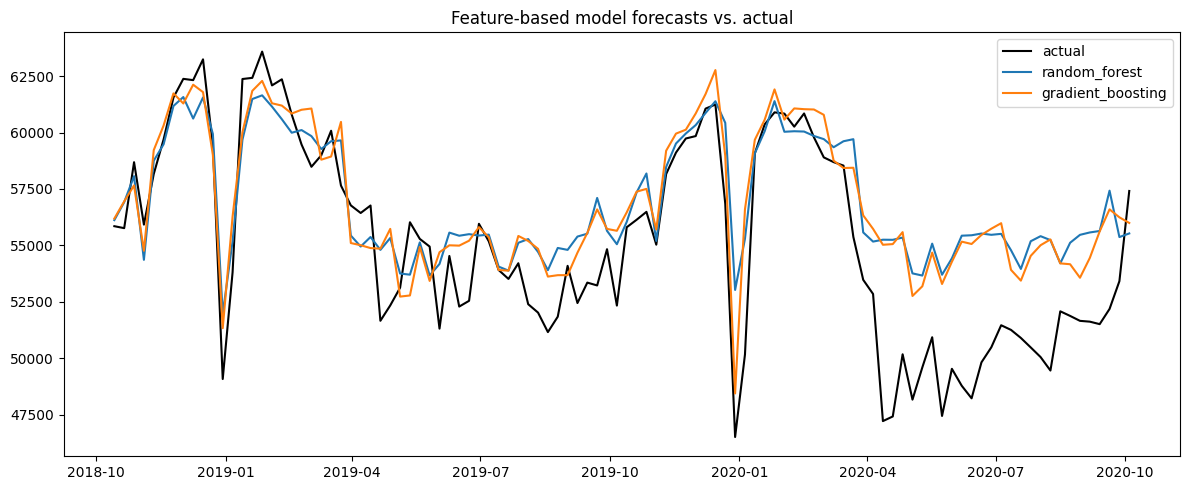

In [16]:
def build_feature_frame(load, temp):
    df = pd.DataFrame({"load_mw": load, "temp_c": temp})
    df["lag_1"] = df["load_mw"].shift(1)
    df["lag_2"] = df["load_mw"].shift(2)
    df["lag_52"] = df["load_mw"].shift(52)
    df["roll_mean_4"] = df["load_mw"].shift(1).rolling(4).mean()
    woy = df.index.isocalendar().week.astype(int)
    df["woy_sin"] = np.sin(2 * np.pi * woy / 52)
    df["woy_cos"] = np.cos(2 * np.pi * woy / 52)
    df["month"] = df.index.month
    return df

FEATURE_COLS = ["temp_c", "lag_1", "lag_2", "lag_52", "roll_mean_4", "woy_sin", "woy_cos", "month"]

def recursive_forecast(model, history_load, future_temp, horizon):
    load_history = history_load.copy()
    preds = []
    for i, ts in enumerate(future_temp.index):
        lag_1, lag_2, lag_52 = load_history.iloc[-1], load_history.iloc[-2], load_history.iloc[-52]
        roll_mean_4 = load_history.iloc[-4:].mean()
        woy = ts.isocalendar().week
        row = pd.DataFrame([{
            "temp_c": future_temp.iloc[i], "lag_1": lag_1, "lag_2": lag_2, "lag_52": lag_52,
            "roll_mean_4": roll_mean_4, "woy_sin": np.sin(2*np.pi*woy/52), "woy_cos": np.cos(2*np.pi*woy/52),
            "month": ts.month,
        }])
        pred = model.predict(row[FEATURE_COLS])[0]
        preds.append(pred)
        load_history = pd.concat([load_history, pd.Series([pred], index=[ts])])
    return pd.Series(preds, index=future_temp.index)

full_feat = build_feature_frame(weekly, temp_weekly)
train_feat = full_feat.iloc[:-HORIZON_WEEKS].dropna()
X_train, y_train = train_feat[FEATURE_COLS], train_feat["load_mw"]

for Model, name in [(RandomForestRegressor, "random_forest"), (GradientBoostingRegressor, "gradient_boosting")]:
    model = Model(n_estimators=300, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    preds = recursive_forecast(model, weekly.iloc[:-HORIZON_WEEKS], test_temp, HORIZON_WEEKS)
    log_result(name, test_w, preds.values)
    if hasattr(model, "feature_importances_"):
        print(name, "feature importances:", dict(zip(FEATURE_COLS, model.feature_importances_.round(3))))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_w.index, test_w.values, label="actual", color="black")
ax.plot(test_w.index, RESULTS["random_forest"]["forecast"], label="random_forest")
ax.plot(test_w.index, RESULTS["gradient_boosting"]["forecast"], label="gradient_boosting")
ax.set_title("Feature-based model forecasts vs. actual"); ax.legend()
fig.tight_layout(); plt.show()


## Part 6: LSTM (hourly data)



In [17]:
from sklearn.preprocessing import MinMaxScaler

LOOKBACK = 168  # 1 week of hourly history
HORIZON_HOURS = 2 * 365 * 24  # ~2 years

scaler = MinMaxScaler().fit(hourly.values.reshape(-1, 1))
scaled = scaler.transform(hourly.values.reshape(-1, 1)).flatten()

train_scaled = scaled[:-HORIZON_HOURS]

def make_windows(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, LOOKBACK)
X_train = X_train.reshape(-1, LOOKBACK, 1)
print("Training windows:", X_train.shape)


Training windows: (32712, 168, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0476 - val_loss: 0.0280
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0125 - val_loss: 0.0040
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0024 - val_loss: 9.9698e-04
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0021 - val_loss: 8.3175e-04
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0019 - val_loss: 7.4153e-04
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0017 - val_loss: 7.0290e-04


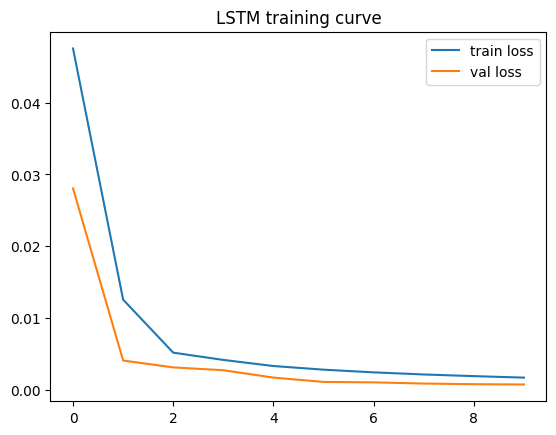

In [18]:
def build_lstm(lookback):
    model = models.Sequential([
        layers.Input(shape=(lookback, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

lstm_model = build_lstm(LOOKBACK)
lstm_model.summary()

# TODO (hyperparameter tuning, per assignment Part 6): try varying LOOKBACK, number/size of
# LSTM layers, dropout rate, and epochs/batch_size, and record validation loss for each -
# a small grid or keras-tuner search is expected here, this is a reasonable starting point.
history = lstm_model.fit(
    X_train, y_train, epochs=10, batch_size=256, validation_split=0.1, verbose=1,
)

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend(); plt.title("LSTM training curve"); plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
lstm: RMSE=1535.1  MAE=1152.0  MAPE=2.13%
lstm_weekly_agg: RMSE=384.9  MAE=302.2  MAPE=0.54%


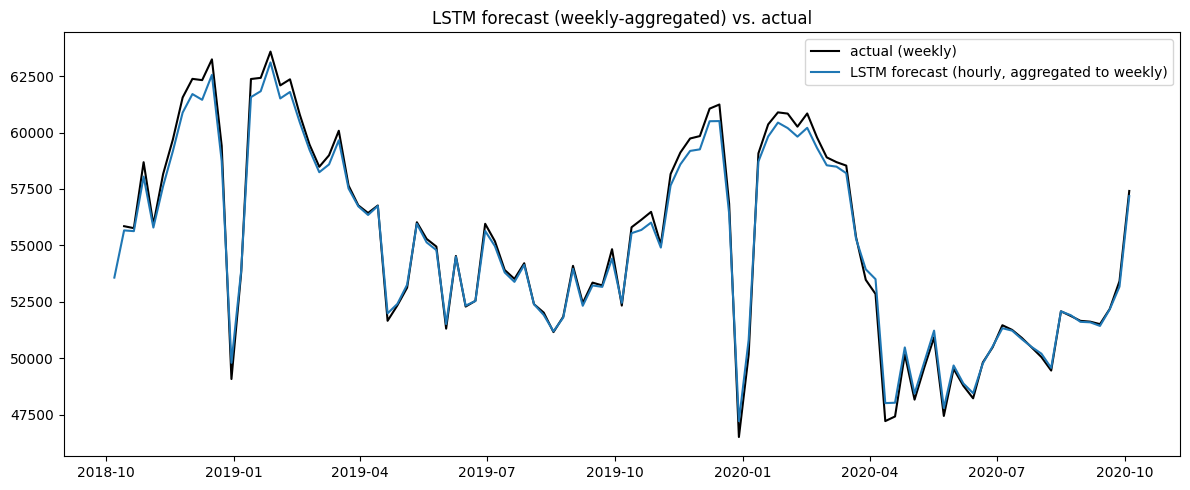

In [19]:
def walk_forward_forecast(model, scaler, series, lookback, horizon):
    """Vectorised one-step-ahead forecast: every input window uses TRUE past
    values (not the model's own predictions), so this can be built and predicted
    in a single batch rather than looping call-by-call."""
    scaled_all = scaler.transform(series.values.reshape(-1, 1)).flatten()
    test_start = len(series) - horizon
    X_test = np.array([scaled_all[test_start + i - lookback: test_start + i] for i in range(horizon)])
    X_test = X_test.reshape(-1, lookback, 1)
    preds_scaled = model.predict(X_test, batch_size=1024, verbose=1).flatten()
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    return pd.Series(preds, index=series.index[-horizon:])

lstm_full_preds = walk_forward_forecast(lstm_model, scaler, hourly, LOOKBACK, HORIZON_HOURS)
lstm_test_actual = hourly.iloc[-HORIZON_HOURS:]
log_result("lstm", lstm_test_actual, lstm_full_preds.values)

# Also aggregate to weekly for a like-for-like comparison against the other (weekly) models
lstm_weekly_pred = lstm_full_preds.resample("W").mean()
lstm_weekly_pred.index.freq = "W-SUN"
log_result("lstm_weekly_agg", test_w, lstm_weekly_pred.reindex(test_w.index).values)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_w.index, test_w.values, label="actual (weekly)", color="black")
ax.plot(lstm_weekly_pred.index, lstm_weekly_pred.values, label="LSTM forecast (hourly, aggregated to weekly)")
ax.set_title("LSTM forecast (weekly-aggregated) vs. actual"); ax.legend()
fig.tight_layout(); plt.show()


## Final model comparison



In [20]:
comparison = pd.DataFrame({name: {"rmse": r["rmse"], "mae": r["mae"], "mape_pct": r["mape_pct"]}
                            for name, r in RESULTS.items() if name != "lstm"}).T  # exclude hourly-resolution lstm row (different units of RMSE)
baseline_rmse = comparison.loc["seasonal_naive", "rmse"]
comparison["pct_improvement_vs_seasonal_naive"] = (baseline_rmse - comparison["rmse"]) / baseline_rmse * 100
comparison = comparison.sort_values("rmse")
comparison


,rmse,mae,mape_pct,pct_improvement_vs_seasonal_naive
lstm_weekly_agg,3.849103e+02,3.022204e+02,5.358233e-01,8.719851e+01
gradient_boosting,2.853429e+03,2.185210e+03,4.188368e+00,5.099573e+00
seasonal_naive,3.006761e+03,2.318521e+03,4.408920e+00,0.000000e+00
random_forest,3.021119e+03,2.277623e+03,4.388129e+00,-4.775145e-01
mean,4.397300e+03,3.788833e+03,6.969238e+00,-4.624707e+01
naive,4.459109e+03,3.783203e+03,6.790082e+00,-4.830274e+01
drift,5.117957e+03,4.339891e+03,8.049685e+00,-7.021498e+01
sarimax_temperature,6.939203e+105,1.056201e+105,1.906388e+102,-2.307867e+104
sarima,inf,1.017041e+203,1.794635e+200,-inf


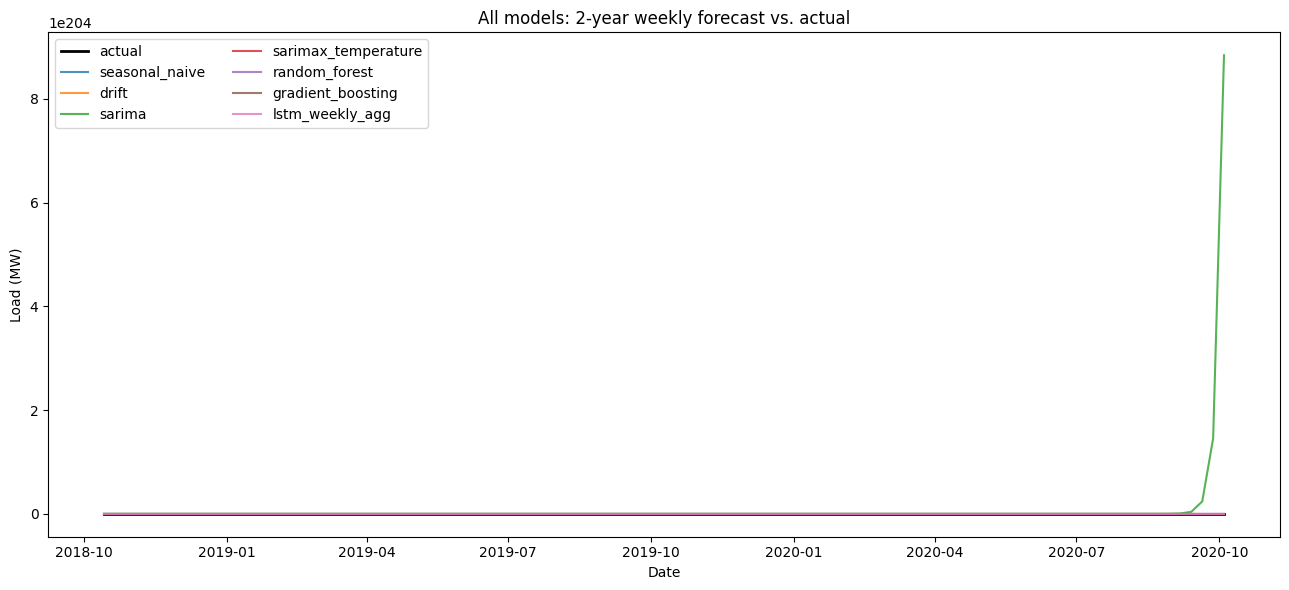

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(test_w.index, test_w.values, label="actual", color="black", linewidth=2)
for name in ["seasonal_naive", "drift", "sarima", "sarimax_temperature", "random_forest",
             "gradient_boosting", "lstm_weekly_agg"]:
    if name in RESULTS:
        ax.plot(test_w.index, RESULTS[name]["forecast"], label=name, alpha=0.8)
ax.set_title("All models: 2-year weekly forecast vs. actual")
ax.set_xlabel("Date"); ax.set_ylabel("Load (MW)")
ax.legend(ncol=2)
fig.tight_layout(); plt.show()
